Churn Modelling Dataset

In [481]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE,SMOTENC,RandomOverSampler
from collections import Counter
df = pd.read_csv(r"D:\Kareem\Machine learning Developer\Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [482]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [483]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [484]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [485]:
print(df.duplicated().sum())

0


In [486]:
df.drop(['CustomerId','Surname','RowNumber'] , inplace = True , axis = 1)

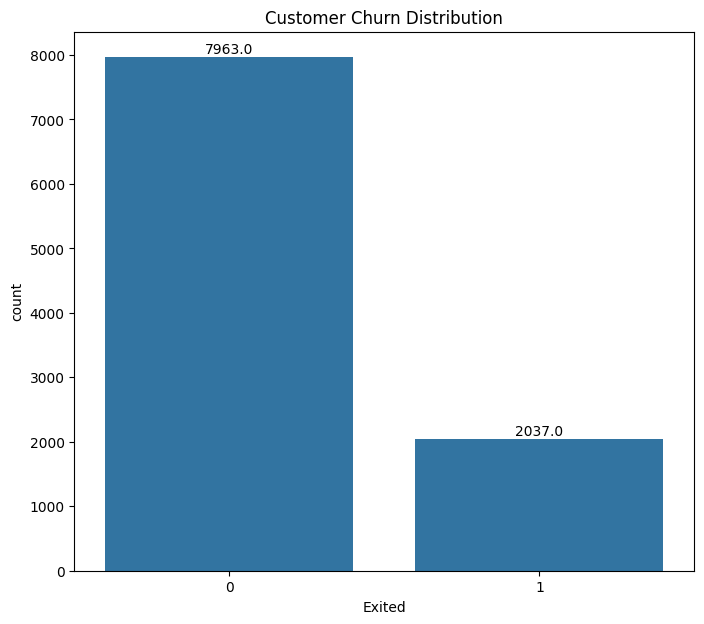

In [487]:
plt.figure(figsize=(8,7))
bars_customer = sns.countplot(x='Exited', data=df)
for bar in bars_customer.patches:               # To find out the number
    high = bar.get_height()
    plt.text(
        bar.get_x() +  bar.get_width()/2,
        high + 60,
        high,
        ha="center"
    )
plt.title("Customer Churn Distribution")
plt.show()

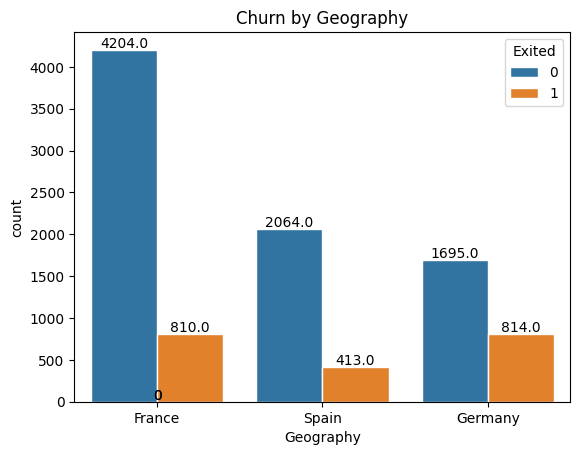

In [488]:
bars_countries = sns.countplot(x='Geography', hue='Exited', data=df,edgecolor="white")
for bar1 in bars_countries.patches:
    high = bar1.get_height()        # To find out the number
    plt.text(
        bar1.get_x() +  bar1.get_width()/2,
        high+25,
        high,
        ha = "center"
    )
plt.title("Churn by Geography")
plt.show()

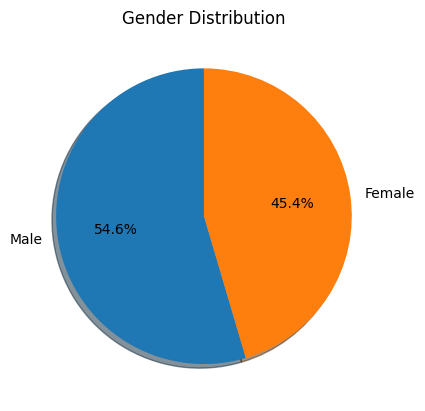

In [489]:
total_gender = df['Gender'].value_counts()
plt.pie(total_gender, labels=total_gender.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title("Gender Distribution")
plt.show()

In [490]:
x = df.drop('Exited', axis=1)
target = df['Exited']
x_train , x_test , target_train , target_test = train_test_split(x,target , train_size = 0.8 , random_state=42)

In [491]:
cat_cols = ['Geography','Gender']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(x_train[cat_cols])
encoded_test = encoder.transform(x_test[cat_cols])

encoded_train_df = pd.DataFrame(
encoded_train,
columns=encoder.get_feature_names_out(cat_cols),
index=x_train.index
)

encoded_test_df = pd.DataFrame(
encoded_test,
columns=encoder.get_feature_names_out(cat_cols),
index=x_test.index)

# train
x_train = x_train.drop(cat_cols, axis=1)
x_train[list(encoded_train_df.columns)] = encoded_train_df

# test
x_test = x_test.drop(cat_cols, axis=1)
x_test[list(encoded_test_df.columns)] = encoded_test_df
x_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,1.0,0.0,0.0,0.0,1.0
1561,632,42,4,119624.60,2,1,1,195978.86,0.0,1.0,0.0,0.0,1.0
1670,559,24,3,114739.92,1,1,0,85891.02,0.0,0.0,1.0,0.0,1.0
6087,561,27,9,135637.00,1,1,0,153080.40,1.0,0.0,0.0,1.0,0.0
6669,517,56,9,142147.32,1,0,0,39488.04,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,54,8,69712.74,1,1,1,69381.05,1.0,0.0,0.0,0.0,1.0
5191,682,58,1,0.00,1,1,1,706.50,1.0,0.0,0.0,1.0,0.0
5390,735,38,1,0.00,3,0,0,92220.12,1.0,0.0,0.0,1.0,0.0
860,667,43,8,190227.46,1,1,0,97508.04,1.0,0.0,0.0,0.0,1.0


In [492]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=3,
    random_state=42
)
X_train_smo, y_train_smo = smote.fit_resample(x_train, target_train)

print("SMOTE:", Counter(y_train_smo))

SMOTE: Counter({0: 6356, 1: 6356})


In [ ]:
num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
scaler = StandardScaler()
X_train_smo = scaler.fit_transform(X_train_smo[num_cols])
x_test = scaler.transform(x_test[num_cols])
X_train_smo


In [494]:
model = RandomForestClassifier(max_depth=8,random_state=42)
model.fit(X_train_smo, y_train_smo)                #training
target_pred_train = model.predict(X_train_smo)      #predict train
target_pred_test = model.predict(x_test)        #predict test

In [495]:
print(classification_report(target_pred_train,y_train_smo))
print(classification_report(target_pred_test,target_test))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89      6777
           1       0.86      0.92      0.89      5935

    accuracy                           0.89     12712
   macro avg       0.89      0.89      0.89     12712
weighted avg       0.89      0.89      0.89     12712

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1627
           1       0.59      0.62      0.60       373

    accuracy                           0.85      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.85      0.85      0.85      2000



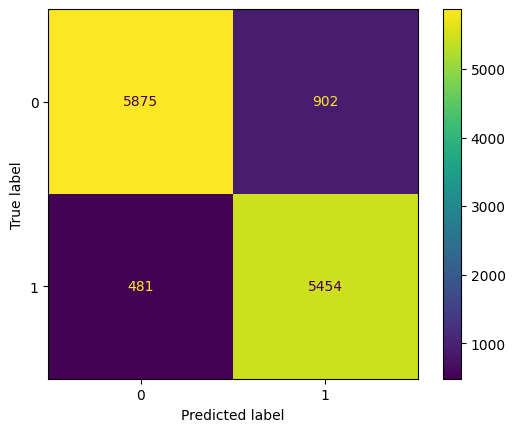

In [496]:
cm_train = confusion_matrix(target_pred_train,y_train_smo)
ConfusionMatrixDisplay(cm_train).plot();

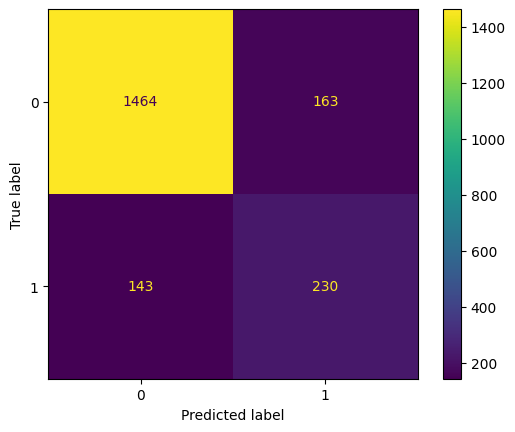

In [497]:
cm_test = confusion_matrix(target_pred_test,target_test)
ConfusionMatrixDisplay(cm_test).plot();